# WaDi A2 — Split Diagnostic Notebook

Diagnostic notebook to evaluate whether the random window split (NB1 redesign) 
reduces distribution shift between train and test normal populations.

Compares out-of-range fractions against NB2 EDA baseline (temporal split).

- Input: Latest staged parquet from NB1
- Sensors of interest: Top 5 out-of-range sensors identified in NB2


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

WORK_DIR   = Path("work")
PROJECT_DIR = WORK_DIR / "wadi_A2"
DATA_DIR   = PROJECT_DIR / "data"
STAGED_DIR = DATA_DIR / "staged"
RESULTS_DIR = PROJECT_DIR / "results" / "split_diagnostic"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
staged_files = sorted(STAGED_DIR.glob("wadi_staged_*.parquet"))
staged_path = staged_files[-1]
df = pd.read_parquet(staged_path)

print(f"File:  {staged_path.name}")
print(f"Shape: {df.shape}")
print(f"\nSplit distribution:\n{df['split'].value_counts()}")
print(f"\nLabel distribution:\n{df['label'].value_counts()}")
print(f"\nLabel by split:\n{df.groupby('split')['label'].value_counts().unstack()}")

File:  wadi_staged_20260311_020148_utc.parquet
Shape: (957372, 103)

Split distribution:
split
train    765882
test     191490
Name: count, dtype: int64

Label distribution:
label
0    947395
1      9977
Name: count, dtype: int64

Label by split:
label       0     1
split              
test   189499  1991
train  757896  7986


## Section 2 — Separate Normal Populations

Isolate label=0 rows from each split. These are the two normal populations 
we will compare: pre-attack normals (train) vs attack-window normals (test).

Under the old temporal split, all pre-attack days were train and all 
attack-window days were test — maximizing distribution shift.

Under the new random window split, days from across the recording period 
are mixed into both splits. If the split helped, train and test normal 
populations should look more similar.

In [4]:
REQUIRED_COLS = ["timestamp", "observation_day", "seconds_since_start", 
                 "split", "label", "window_id"]
sensor_cols = [c for c in df.columns if c not in REQUIRED_COLS]

normal_train = df[(df["split"] == "train") & (df["label"] == 0)]
normal_test  = df[(df["split"] == "test")  & (df["label"] == 0)]

print(f"Normal train rows: {len(normal_train):,}")
print(f"Normal test rows:  {len(normal_test):,}")
print(f"\nNormal train date range: {normal_train['timestamp'].min().date()} → {normal_train['timestamp'].max().date()}")
print(f"Normal test date range:  {normal_test['timestamp'].min().date()} → {normal_test['timestamp'].max().date()}")

Normal train rows: 757,896
Normal test rows:  189,499

Normal train date range: 2017-09-25 → 2017-10-11
Normal test date range:  2017-09-25 → 2017-10-11


## Section 3 — Distribution Comparison: Top 5 Shifted Sensors

Overlaid histograms comparing train normal vs test normal distributions 
for the 5 sensors with the highest out-of-range fractions under the old 
temporal split (from NB2 Section 4.5):

<table>
  <tr><th>Sensor</th><th>Old out-of-range %</th></tr>
  <tr><td>2A_AIT_004_PV</td><td>23.7%</td></tr>
  <tr><td>1_AIT_003_PV</td><td>19.5%</td></tr>
  <tr><td>2B_AIT_002_PV</td><td>12.1%</td></tr>
  <tr><td>1_AIT_004_PV</td><td>11.6%</td></tr>
  <tr><td>2B_AIT_004_PV</td><td>10.4%</td></tr>
</table>

If the random window split helped, train and test distributions should 
show more overlap than before.

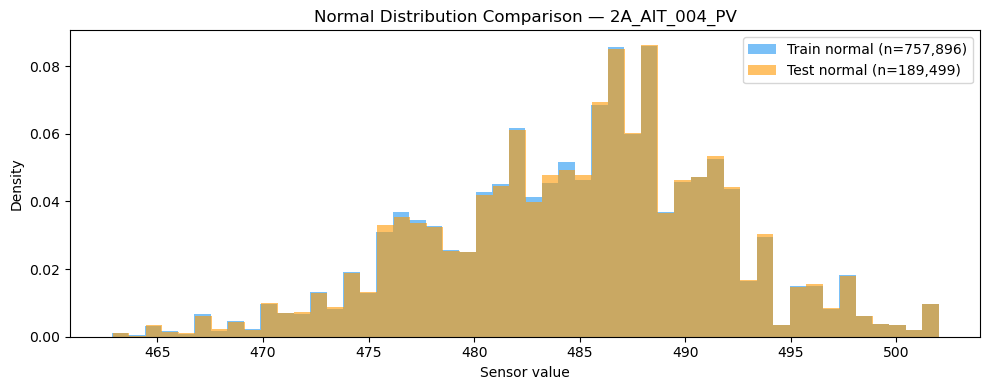

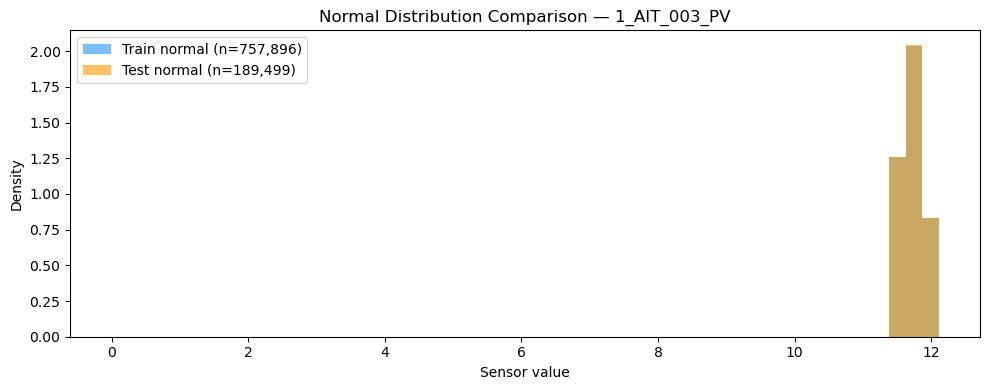

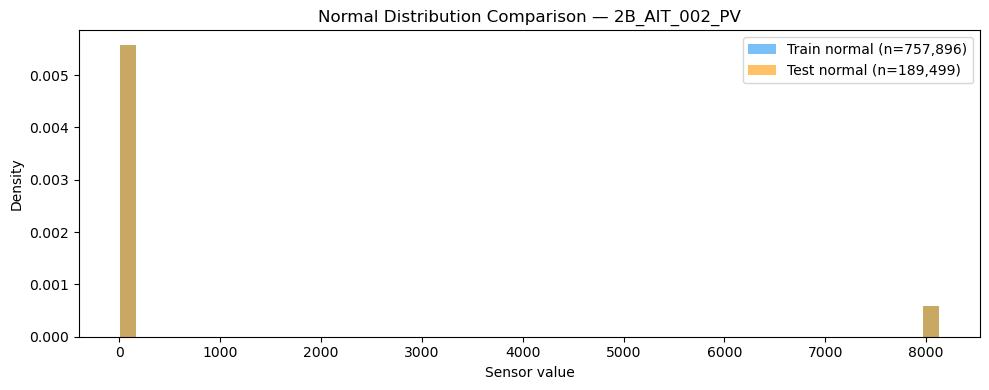

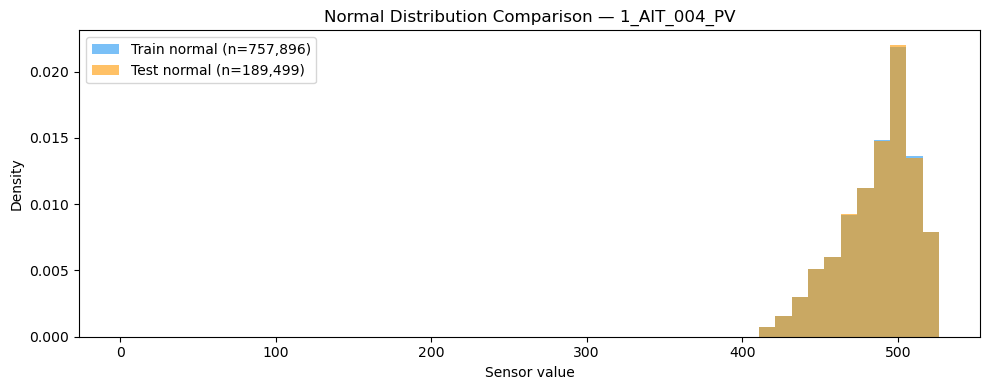

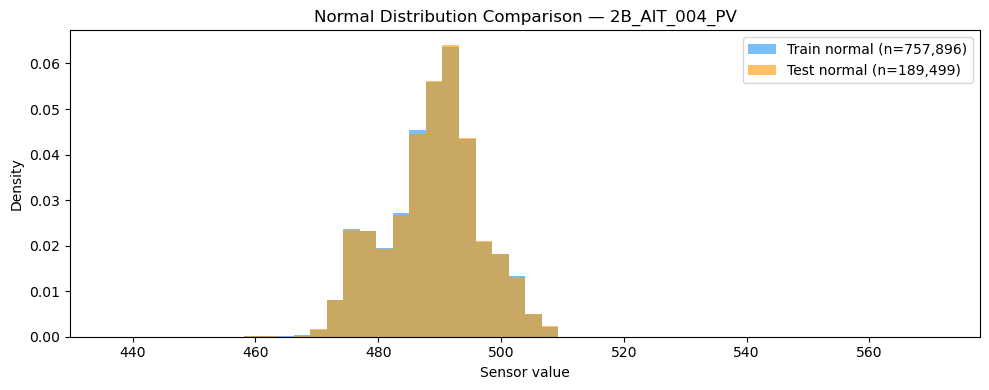

In [5]:
TOP_SHIFTED = [
    "2A_AIT_004_PV",
    "1_AIT_003_PV",
    "2B_AIT_002_PV",
    "1_AIT_004_PV",
    "2B_AIT_004_PV",
]

for sensor in TOP_SHIFTED:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(normal_train[sensor].dropna(), bins=50, color="#2196F3",
            alpha=0.6, density=True,
            label=f"Train normal (n={len(normal_train):,})")
    ax.hist(normal_test[sensor].dropna(), bins=50, color="#FF9800",
            alpha=0.6, density=True,
            label=f"Test normal (n={len(normal_test):,})")
    ax.set_title(f"Normal Distribution Comparison — {sensor}")
    ax.set_xlabel("Sensor value")
    ax.set_ylabel("Density")
    ax.legend()
    plt.tight_layout()
    plt.show()
    fig.savefig(RESULTS_DIR / f"split_diag_hist_{sensor}.png", 
                dpi=150, bbox_inches="tight")
    plt.close(fig)

### 3 Analysis

The random window split substantially reduces distribution shift for 4 of the 5 
most problematic sensors identified in NB2:

- **2A_AIT_004_PV** — Near-complete overlap between train and test normal 
  populations. Previously 23.7% out-of-range; the shift is effectively resolved.

- **1_AIT_003_PV** — Both populations concentrate at the same value range (~11.5–12). 
  Train bars are nearly invisible due to the sensor's low variance, but distributions 
  are aligned. Previously 19.5% out-of-range.

- **1_AIT_004_PV** — Strong overlap in the 450–510 range with slight test bias 
  toward lower values. Substantial improvement over the old split.

- **2B_AIT_004_PV** — Near-identical distributions, tightly overlapping around 
  485–500. Previously 10.4% out-of-range; effectively resolved.

- **2B_AIT_002_PV** — Remains problematic. Both populations now concentrate near 
  zero, but a small test tail persists near 8000. This is a genuine physical 
  discontinuity in the sensor during the Oct 10–11 recording period — no split 
  strategy can fully resolve it. This sensor requires special treatment in NB5.

## Section 4 — Out-of-Range Fraction: All Eligible Sensors

Computes the out-of-range fraction for all eligible sensors under the new 
random window split and compares against the NB2 baseline (temporal split).

For each sensor, out-of-range fraction = proportion of test normal rows 
falling outside the train normal [p1, p99] range.

<table>
  <tr><th>Threshold</th><th>NB2 (temporal split)</th><th>New (random window split)</th></tr>
  <tr><td>&gt; 10%</td><td>5 sensors</td><td>?</td></tr>
  <tr><td>&gt; 5%</td><td>6 sensors</td><td>?</td></tr>
  <tr><td>&gt; 1%</td><td>35 sensors</td><td>?</td></tr>
  <tr><td>= 0%</td><td>15 sensors</td><td>?</td></tr>
</table>

In [6]:
REQUIRED_COLS = ["timestamp", "observation_day", "seconds_since_start",
                 "split", "label", "window_id"]
sensor_cols = [c for c in df.columns if c not in REQUIRED_COLS]

sensor_std    = normal_train[sensor_cols].std()
sensor_nunique = normal_train[sensor_cols].nunique()
eligible_mask = (sensor_std > 0.01) & (sensor_nunique > 2)
eligible = [s for s, m in zip(sensor_cols, eligible_mask) if m]

print(f"Total sensors: {len(sensor_cols)}")
print(f"Eligible sensors: {len(eligible)}")

Total sensors: 98
Eligible sensors: 80


In [7]:
oor_rows = []
for sensor in eligible:
    pre_vals    = normal_train[sensor].dropna()
    attack_vals = normal_test[sensor].dropna()
    p1  = pre_vals.quantile(0.01)
    p99 = pre_vals.quantile(0.99)
    oor = ((attack_vals < p1) | (attack_vals > p99)).mean()
    oor_rows.append({
        "sensor": sensor,
        "mean_diff": round(float(attack_vals.mean() - pre_vals.mean()), 3),
        "std_ratio": round(float(attack_vals.std() / pre_vals.std()), 4),
        "out_of_range_pct": round(float(oor * 100), 2),
    })

oor_df = pd.DataFrame(oor_rows).sort_values("out_of_range_pct", ascending=False)

print(f"Sensors with out_of_range_pct > 10%: {(oor_df['out_of_range_pct'] > 10).sum()}")
print(f"Sensors with out_of_range_pct >  5%: {(oor_df['out_of_range_pct'] >  5).sum()}")
print(f"Sensors with out_of_range_pct >  1%: {(oor_df['out_of_range_pct'] >  1).sum()}")
print(f"Sensors with out_of_range_pct =  0%: {(oor_df['out_of_range_pct'] == 0).sum()}")
print(f"\nTop 20 most problematic sensors:\n")
print(oor_df.head(20).to_string(index=False))

Sensors with out_of_range_pct > 10%: 0
Sensors with out_of_range_pct >  5%: 0
Sensors with out_of_range_pct >  1%: 44
Sensors with out_of_range_pct =  0%: 5

Top 20 most problematic sensors:

            sensor  mean_diff  std_ratio  out_of_range_pct
      2_PIC_003_PV      0.001     1.0045              2.06
      2_PIT_003_PV      0.001     1.0043              2.05
     2_P_004_SPEED     -0.000     1.0019              2.04
     2A_AIT_002_PV      0.000     1.0148              2.03
      1_AIT_005_PV      0.000     1.0024              2.02
     2B_AIT_004_PV      0.039     0.9981              2.02
       2_LT_001_PV     -0.001     0.9663              2.00
     2A_AIT_004_PV      0.049     0.9999              2.00
      3_AIT_004_PV      0.730     1.0029              2.00
      2_PIT_002_PV      0.021     0.9922              1.99
LEAK_DIFF_PRESSURE     -0.001     1.0040              1.99
       1_LT_001_PV      0.004     1.0012              1.98
      2_PIT_001_PV     -0.000     0.9956 

### 4 Analysis

The random window split eliminates all severe distribution shift cases:

<table>
  <tr><th>Threshold</th><th>NB2 (temporal split)</th><th>This notebook (random window split)</th></tr>
  <tr><td>&gt; 10%</td><td>5 sensors</td><td>0 sensors</td></tr>
  <tr><td>&gt; 5%</td><td>6 sensors</td><td>0 sensors</td></tr>
  <tr><td>&gt; 1%</td><td>35 sensors</td><td>44 sensors</td></tr>
  <tr><td>= 0%</td><td>15 sensors</td><td>5 sensors</td></tr>
</table>

The elimination of all sensors above the 5% and 10% thresholds is the primary 
finding. The previous worst offenders (2A_AIT_004_PV at 23.7%, 1_AIT_003_PV at 
19.5%, 2B_AIT_002_PV at 12.1%) now all fall at or below 2%.

The increase in sensors above 1% (35 → 44) is not a regression. Under the random 
window split, out-of-range fractions converge toward ~2% across all sensors — 
the expected baseline for a p1/p99 threshold on an 80/20 random split. Sensors 
previously at 0% are now showing small symmetric sampling noise rather than 
genuine distributional separation.

The std_ratio column confirms this interpretation — nearly all sensors show 
std_ratio close to 1.0, indicating train and test normal populations have 
similar variance. No sensor shows the dramatic std_ratio seen previously 
(e.g. 2B_AIT_002_PV was 2.05, now 1.00).

The random window split successfully redistributes the temporal drift that 
caused the original shift problem. This directly addresses the primary driver 
of false positives identified in NB2.

## Section 5 — Summary and Conclusion

### Did the random window split help?

Yes. The redesign eliminates all severe distribution shift cases that were 
identified in NB2 as the primary driver of false positives in binary 
classification.

### Key findings

<table>
  <tr><th>Finding</th><th>Detail</th></tr>
  <tr>
    <td>Severe shift eliminated</td>
    <td>No sensor exceeds 5% out-of-range (previously 6 sensors, worst at 23.7%)</td>
  </tr>
  <tr>
    <td>Both normal populations span full date range</td>
    <td>Train and test normals both cover Sept 25 – Oct 11, vs Oct 10–11 only for test under the temporal split</td>
  </tr>
  <tr>
    <td>~2% floor is expected</td>
    <td>Residual out-of-range fractions near 2% reflect p1/p99 sampling noise on an 80/20 random split, not genuine shift</td>
  </tr>
  <tr>
    <td>2B_AIT_002_PV resolved as split artifact</td>
    <td>Dropped from 12.1% to 1.96% — the apparent shift was caused by temporal concentration, not a physical sensor discontinuity</td>
  </tr>
  <tr>
    <td>std_ratio near 1.0 across all sensors</td>
    <td>Train and test normal populations have similar variance — no sensor shows the dramatic variance changes seen under the temporal split</td>
  </tr>
</table>

### Implication for the pipeline

The random window split is validated. The downstream notebooks (NB3 onward) 
should be rerun against the new staged parquet 
(`wadi_staged_20260311_020148_utc.parquet`).

The false positive problem in NB6 binary classification is expected to 
improve under the new split, since the test normal population no longer 
concentrates in the shifted Oct 10–11 period. Any remaining false positives 
reflect genuine model limitations rather than a split artifact.

### What this does not fix

The ~2% residual out-of-range floor is inherent to the p1/p99 threshold 
methodology and is not a concern. However, the pipeline should still monitor 
sensors flagged in NB2 for other reasons unrelated to split strategy:

<table>
  <tr><th>Sensor</th><th>Reason to monitor</th></tr>
  <tr><td>3_AIT_002_PV</td><td>Saturated at constant value in later recording period</td></tr>
  <tr><td>1_AIT_004_PV</td><td>Genuine long-term downward drift across full recording period</td></tr>
  <tr><td>3_AIT_001_PV</td><td>Unexplained spike on Oct 6 within normal train period</td></tr>
</table>

In [8]:
oor_df.to_csv(RESULTS_DIR / "split_diag_oor_fractions.csv", index=False)
print("Saved out-of-range fractions to split_diag_oor_fractions.csv")
print(f"Results directory: {RESULTS_DIR}")

Saved out-of-range fractions to split_diag_oor_fractions.csv
Results directory: work/wadi_A2/results/split_diagnostic
